# Regression Models

In this notebook, machine learning regression models are trained to predict the numerical `stress_level` value.

The target variable is `stress_level`, which ranges from 1 to 10.

The goal is to compare different regression models and evaluate their prediction performance using MAE, RMSE, and R² score.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# Step 1: Loading the Processed Dataset

In this step, the processed dataset saved during preprocessing is loaded.

This dataset already includes encoded categorical variables and engineered features.

In [2]:
PROJECT_DIR = Path(r"C:\Users\onury\OneDrive\Masaüstü\Machine Learning\ML-Stress-Level-Prediction")

processed_path = PROJECT_DIR / "data" / "processed" / "processed_health_indicators.csv"

df = pd.read_csv(processed_path)

df.head()

,age,steps_per_day,active_minutes,sedentary_minutes,sleep_hours,sleep_quality,stress_level,workouts_per_week,diet_quality,hydration_liters,...,heart_rate_avg,consistency_score,lifestyle_category_Athlete,lifestyle_category_Sedentary,fitness_level_Moderate,fitness_level_Unfit,activity_ratio,sleep_deficit,heart_rate_difference,stress_category
0,56,12633,122,1084,8.65,8.67,4.42,2,5.61,2.14,...,103.0,3.84,False,False,True,False,0.101161,0.65,48.2,Medium
1,46,1980,33,1122,5.97,5.37,7.91,2,8.17,0.92,...,126.3,7.25,False,False,False,True,0.028571,2.03,51.1,High
2,32,7139,60,1049,6.23,7.15,4.20,0,3.47,2.67,...,101.4,5.77,False,True,False,True,0.054103,1.77,35.1,Medium
3,60,4814,66,1018,5.09,7.61,7.12,4,5.26,2.17,...,107.8,9.11,False,False,True,False,0.060886,2.91,43.2,High
4,25,8096,86,1031,5.49,5.57,3.88,3,2.60,2.91,...,92.8,7.55,False,False,True,False,0.076992,2.51,28.8,Low


In [3]:
print("Dataset shape:", df.shape)
print("Columns:")
for col in df.columns:
    print("-", col)

Dataset shape: (1000000, 22)
Columns:
- age
- steps_per_day
- active_minutes
- sedentary_minutes
- sleep_hours
- sleep_quality
- stress_level
- workouts_per_week
- diet_quality
- hydration_liters
- bmi
- heart_rate_resting
- heart_rate_avg
- consistency_score
- lifestyle_category_Athlete
- lifestyle_category_Sedentary
- fitness_level_Moderate
- fitness_level_Unfit
- activity_ratio
- sleep_deficit
- heart_rate_difference
- stress_category


# Step 2: Preparing Data for Regression

For the regression task, the target variable is the numerical `stress_level` column.

The `stress_category` column is also removed from the input features because it was created from `stress_level`.

Keeping `stress_category` in the input data would cause data leakage.

In [4]:
X = df.drop(columns=["stress_level", "stress_category"])
y = df["stress_level"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("stress_level in X:", "stress_level" in X.columns)
print("stress_category in X:", "stress_category" in X.columns)

X shape: (1000000, 20)
y shape: (1000000,)
stress_level in X: False
stress_category in X: False


# Step 3: Train-Test Split

The dataset is split into training and testing sets.

80% of the data is used for training, and 20% is used for testing.

The testing set is used to evaluate how well the regression models perform on unseen data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800000, 20)
X_test shape: (200000, 20)
y_train shape: (800000,)
y_test shape: (200000,)


# Step 4: Linear Regression Model

Linear Regression is used as the baseline regression model.

A baseline model provides a simple reference point for comparing more advanced models.

In [6]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R² Score:", r2_linear)

Linear Regression Results
MAE: 1.140825777211728
RMSE: 1.4189695351088432
R² Score: 0.40008309145041465


## Interpretation of Linear Regression Results

Linear Regression was used as the baseline regression model.

The model achieved an MAE of approximately 1.14, which means that the predicted stress level differs from the actual stress level by about 1.14 points on average.

The RMSE value is approximately 1.42, indicating that some prediction errors are larger than the average absolute error.

The R² score is approximately 0.40, meaning that the model explains about 40% of the variance in the numerical `stress_level` values.

Since Linear Regression is a simple linear model, it may not fully capture non-linear relationships in the dataset. Therefore, more advanced models will be tested next.

# Step 5: Decision Tree Regressor

Decision Tree Regressor is used as a non-linear regression model.

Unlike Linear Regression, Decision Tree can capture non-linear patterns in the dataset.

In this experiment, `max_depth=10` is used to control model complexity and reduce overfitting.

In [7]:
decision_tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regressor Results")
print("MAE:", mae_tree)
print("RMSE:", rmse_tree)
print("R² Score:", r2_tree)

Decision Tree Regressor Results
MAE: 0.7948461007052054
RMSE: 1.0567539698238493
R² Score: 0.6672694056050568


## Interpretation of Decision Tree Regressor Results

Decision Tree Regressor achieved better performance than the baseline Linear Regression model.

The MAE decreased from approximately 1.14 to 0.79, meaning that the average prediction error became smaller.

The RMSE also decreased from approximately 1.42 to 1.06, showing that larger prediction errors were reduced.

The R² score increased from approximately 0.40 to 0.67. This means that the Decision Tree model explains about 67% of the variance in the numerical `stress_level` values.

These results suggest that the relationship between health and lifestyle indicators and stress level may include non-linear patterns that Linear Regression cannot fully capture.

# Step 6: Regression Model Comparison

In this step, the regression models are compared using MAE, RMSE, and R² score.

Lower MAE and RMSE values indicate better prediction accuracy.

A higher R² score indicates that the model explains more variance in the target variable.

In [8]:
regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regressor"],
    "MAE": [mae_linear, mae_tree],
    "RMSE": [rmse_linear, rmse_tree],
    "R2 Score": [r2_linear, r2_tree]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.140826,1.418970,0.400083
1,Decision Tree Regressor,0.794846,1.056754,0.667269


## Interpretation of Regression Model Comparison

The comparison table shows that Decision Tree Regressor outperformed Linear Regression on all evaluation metrics.

Decision Tree Regressor achieved a lower MAE and RMSE, which means it made smaller prediction errors.

It also achieved a higher R² score, indicating that it explained more variance in the stress level values.

Based on these results, Decision Tree Regressor is currently the better regression model among the tested models.

# Step 7: Random Forest Regressor

Random Forest Regressor is an ensemble learning model that combines multiple decision trees.

It usually provides more stable predictions than a single Decision Tree because it averages the predictions of many trees.

Since the dataset is very large, a sample of 100,000 training records is used in this experiment to reduce training time.

In [9]:
from sklearn.ensemble import RandomForestRegressor

In [10]:
X_train_rf_sample = X_train.sample(n=100000, random_state=42)
y_train_rf_sample = y_train.loc[X_train_rf_sample.index]

print("Random Forest training sample shape:", X_train_rf_sample.shape)
print("Random Forest target sample shape:", y_train_rf_sample.shape)

Random Forest training sample shape: (100000, 20)
Random Forest target sample shape: (100000,)


In [11]:
random_forest_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train_rf_sample, y_train_rf_sample)

y_pred_rf = random_forest_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Regressor Results
MAE: 0.7914273854278255
RMSE: 1.047084821807142
R² Score: 0.6733304243476379


## Interpretation of Random Forest Regressor Results

Random Forest Regressor achieved slightly better performance than the single Decision Tree Regressor.

The MAE decreased to approximately 0.79, and the RMSE decreased to approximately 1.05.

The R² score increased to approximately 0.67, meaning that the model explains about 67% of the variance in the numerical `stress_level` values.

Although Random Forest was trained on a sample of 100,000 training records to reduce training time, it still performed slightly better than the Decision Tree model trained on the full training set.

This suggests that ensemble-based models can provide more stable and accurate predictions than a single decision tree.

In [12]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf
    ],
    "R2 Score": [
        r2_linear,
        r2_tree,
        r2_rf
    ]
})

regression_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.140826,1.418970,0.400083
1,Decision Tree Regressor,0.794846,1.056754,0.667269
2,Random Forest Regressor,0.791427,1.047085,0.673330


## Updated Regression Model Comparison

After adding Random Forest Regressor, the model comparison shows that tree-based models perform better than Linear Regression.

Linear Regression has the highest MAE and RMSE values and the lowest R² score.

Decision Tree Regressor significantly improves the results by capturing non-linear relationships.

Random Forest Regressor achieves the best performance so far, with the lowest MAE and RMSE and the highest R² score.

Based on the current results, Random Forest Regressor is the best regression model among the tested models.

# Step 8: Gradient Boosting Regressor

Gradient Boosting is another ensemble learning method that builds models sequentially.

Each new model tries to correct the errors made by the previous models.

In this notebook, `HistGradientBoostingRegressor` is used because it is more efficient for large tabular datasets.

In [13]:
from sklearn.ensemble import HistGradientBoostingRegressor

In [14]:
gradient_boosting_model = HistGradientBoostingRegressor(
    max_iter=100,
    max_leaf_nodes=31,
    learning_rate=0.1,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor Results")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R² Score:", r2_gb)

Gradient Boosting Regressor Results
MAE: 0.7802718000180362
RMSE: 1.0296218011569758
R² Score: 0.6841357901849925


## Interpretation of Gradient Boosting Regressor Results

Gradient Boosting Regressor achieved the best regression performance so far.

The MAE decreased to approximately 0.78, meaning that the model's predictions differ from the actual stress level by about 0.78 points on average.

The RMSE value decreased to approximately 1.03, which shows that larger prediction errors were also reduced compared to the previous models.

The R² score increased to approximately 0.68, meaning that the model explains about 68% of the variance in the numerical `stress_level` values.

These results show that Gradient Boosting captures the relationships in the dataset better than Linear Regression, Decision Tree, and Random Forest.

# Step 9: Final Regression Model Comparison

In this step, all regression models are compared using MAE, RMSE, and R² score.

The tested models are:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

In [15]:
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],
    "MAE": [
        mae_linear,
        mae_tree,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_linear,
        rmse_tree,
        rmse_rf,
        rmse_gb
    ],
    "R2 Score": [
        r2_linear,
        r2_tree,
        r2_rf,
        r2_gb
    ]
})

regression_results = regression_results.sort_values(by="R2 Score", ascending=False)

regression_results

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting Regressor,0.780272,1.029622,0.684136
2,Random Forest Regressor,0.791427,1.047085,0.673330
1,Decision Tree Regressor,0.794846,1.056754,0.667269
0,Linear Regression,1.140826,1.418970,0.400083


## Interpretation of Final Regression Model Comparison

The final regression comparison shows that Gradient Boosting Regressor achieved the best overall performance.

It has the lowest MAE and RMSE values, which means it made the smallest prediction errors among the tested models.

It also has the highest R² score, indicating that it explains the largest amount of variance in the numerical `stress_level` values.

Linear Regression performed the weakest, which suggests that the relationship between the input features and stress level is not purely linear.

Tree-based and ensemble-based models performed better because they can capture non-linear patterns in the dataset.

Based on these results, Gradient Boosting Regressor is selected as the best regression model.

# Step 10: Visualizing Regression Model Performance

In this step, the regression model results are visualized to compare model performance more clearly.

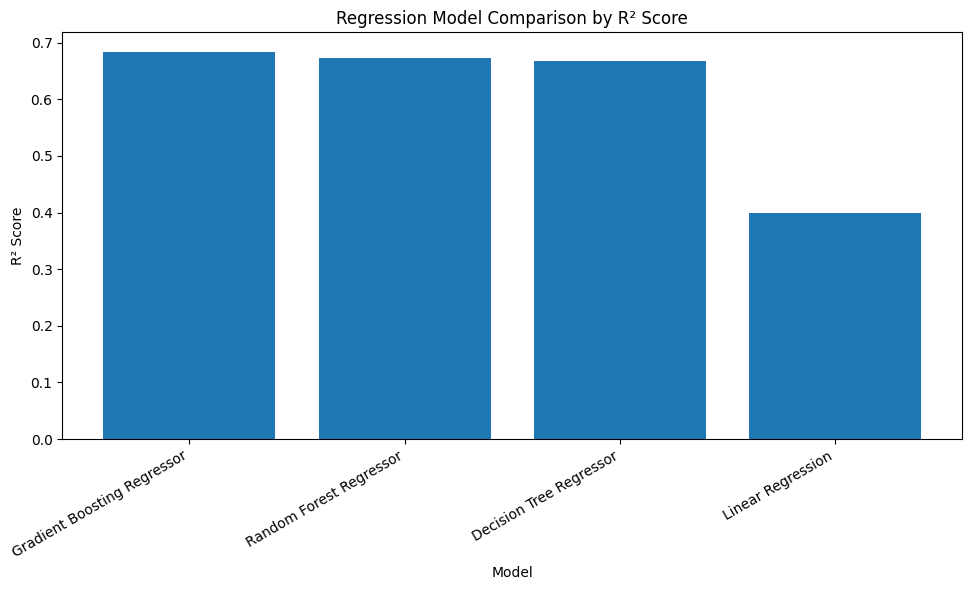

In [20]:
plt.figure(figsize=(10, 6))

plt.bar(regression_results["Model"], regression_results["R2 Score"])

plt.title("Regression Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

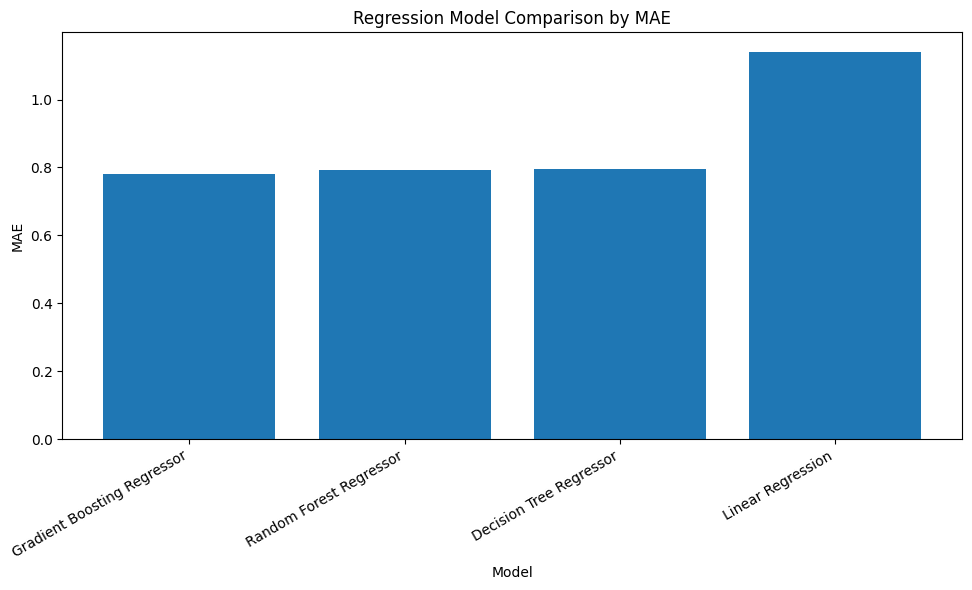

In [21]:
plt.figure(figsize=(10, 6))

plt.bar(regression_results["Model"], regression_results["MAE"])

plt.title("Regression Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

## Interpretation of Regression Performance Visualizations

The R² score chart shows that Gradient Boosting Regressor achieved the highest explanatory power among the regression models.

The MAE chart shows that Gradient Boosting Regressor also produced the lowest average prediction error.

Overall, the visual comparison confirms that ensemble-based models performed better than the baseline Linear Regression model.

# Step 11: Actual vs Predicted Values

In this step, the actual stress levels are compared with the predicted stress levels of the best regression model.

Gradient Boosting Regressor is used because it achieved the best regression performance.

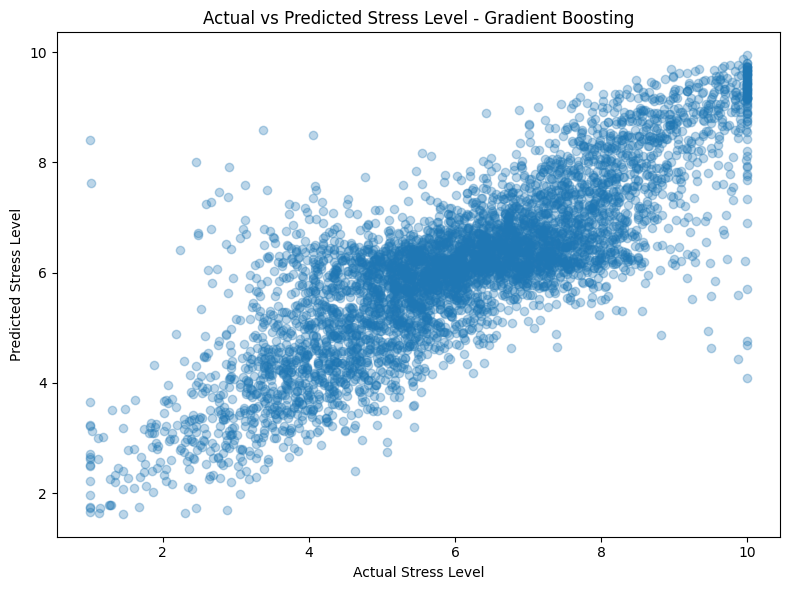

In [22]:
sample_indices = np.random.RandomState(42).choice(len(y_test), size=5000, replace=False)

y_test_sample = y_test.iloc[sample_indices]
y_pred_gb_sample = y_pred_gb[sample_indices]

plt.figure(figsize=(8, 6))

plt.scatter(y_test_sample, y_pred_gb_sample, alpha=0.3)

plt.title("Actual vs Predicted Stress Level - Gradient Boosting")
plt.xlabel("Actual Stress Level")
plt.ylabel("Predicted Stress Level")

plt.tight_layout()
plt.show()

## Interpretation of Actual vs Predicted Plot

The actual vs predicted plot compares the real stress level values with the predictions produced by the Gradient Boosting Regressor.

The points generally follow an upward diagonal pattern, which means that the model captures the overall relationship between the actual and predicted stress levels.

However, the points are not perfectly aligned, which shows that prediction errors still exist.

Overall, the plot supports the numerical evaluation results and shows that Gradient Boosting Regressor performs reasonably well for predicting stress level.

# Step 12: Regression Modeling Summary

In this notebook, four regression models were trained and evaluated to predict the numerical `stress_level` value.

The tested models were:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

The models were evaluated using MAE, RMSE, and R² score.

Linear Regression was used as the baseline model. It achieved the weakest performance, which suggests that the relationship between the features and stress level is not purely linear.

Tree-based and ensemble-based models performed better because they can capture non-linear relationships in the dataset.

Gradient Boosting Regressor achieved the best overall regression performance, with the lowest MAE and RMSE values and the highest R² score.

Based on these results, Gradient Boosting Regressor was selected as the best regression model.

In [23]:
results_path = PROJECT_DIR / "reports"
results_path.mkdir(parents=True, exist_ok=True)

regression_results.to_csv(results_path / "regression_model_results.csv", index=False)

print("Regression results saved successfully.")

Regression results saved successfully.
